In [1]:
import numpy as np
import torch
import torch.nn as nn
from envs.linear_bandit import SimulatorTorchWrapper

In [2]:
class MLP(nn.Module):
    def __init__(self, d):
        super(MLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(d, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self,x):
        x = self.fc(x)
        return x

In [3]:
np.random.seed(123)
torch.manual_seed(123)
k = 10
n = 500000
n_te = 50000

nonlinear_env = SimulatorTorchWrapper(k=k, linear=False)
X = nonlinear_env.generate_batch(n)
A = torch.randint(0, k, (n,))
Afeat = nonlinear_env.get_action_features(A)
Y, true_scores = nonlinear_env.generate_reward(A)

print(X.shape, Afeat.shape)
Z = torch.cat([X, Afeat], dim=1)
print(Z.shape)

Ztr, Zte = Z[:n - n_te], Z[n - n_te:]
Ytr, Yte = Y[:n - n_te], Y[n - n_te:]

torch.Size([500000, 5]) torch.Size([500000, 3])
torch.Size([500000, 8])


In [4]:
policy = MLP(Z.shape[1])
optimizer = torch.optim.SGD(policy.parameters(), lr=0.01)

lossi  = []
n_epochs = 200000
batch_size = 64

for i in range(n_epochs):
    ix = torch.randint(0, Ztr.shape[0], (batch_size,))
    Zb, Yb = Ztr[ix], Ytr[ix]

    y_pred = policy(Zb)
    loss = torch.nn.BCEWithLogitsLoss()(y_pred.reshape(-1), Yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{n_epochs:7d}: {loss.item():.4f}')
    lossi.append(loss.item())

      0/ 200000: 0.6930
  10000/ 200000: 0.3715
  20000/ 200000: 0.4025
  30000/ 200000: 0.2715
  40000/ 200000: 0.3628
  50000/ 200000: 0.3630
  60000/ 200000: 0.3182
  70000/ 200000: 0.3428
  80000/ 200000: 0.3104
  90000/ 200000: 0.2843
 100000/ 200000: 0.4025
 110000/ 200000: 0.3057
 120000/ 200000: 0.2803
 130000/ 200000: 0.2800
 140000/ 200000: 0.3243
 150000/ 200000: 0.3642
 160000/ 200000: 0.2835
 170000/ 200000: 0.3521
 180000/ 200000: 0.2961
 190000/ 200000: 0.4677


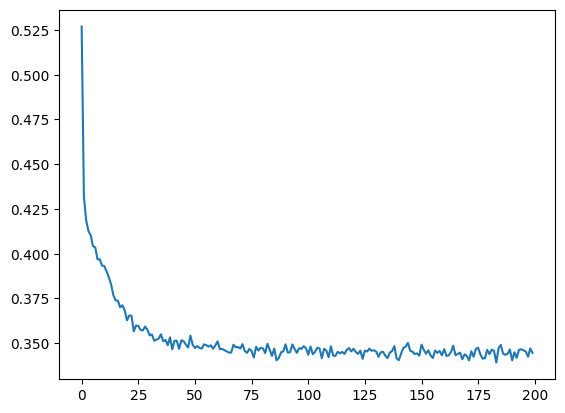

In [5]:
import matplotlib.pyplot as plt
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1));

In [6]:
with torch.no_grad():
    policy.eval()
    scores_pred_te = policy(Zte).reshape(-1)
print(((scores_pred_te - true_scores.gather(1, A.unsqueeze(1)).squeeze(1)[n-n_te:]) ** 2).sum() / n_te)

tensor(0.3087)


In [7]:
scores_pred_te

tensor([-1.4607, -1.1383, -0.6220,  ..., -3.1852,  1.0833, -0.7317])

In [8]:
true_scores.gather(1, A.unsqueeze(1)).squeeze(1)[n-n_te:]

tensor([-1.8278, -1.2575, -0.7949,  ..., -3.4408,  0.8903, -0.9434])

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader

class ContextualBanditDataset(Dataset):
    """Custom Dataset for Contextual Bandit data."""

    def __init__(self, data):
        """
        Args:
            data (torch.Tensor): Tensor of shape [n, d+k] where
                n = number of contexts, d = context dimensions, k = number of arms.
        """
        self.data = data
        self.context_dim = data.shape[1] - (data.shape[1] // 2)  # Guessing 50% for reward part

    def __len__(self):
        return self.data.size(0)

    def __getitem__(self, idx):
        context = self.data[idx, :self.context_dim+1]
        rewards = self.data[idx, self.context_dim+1:]
        optimal_action = torch.argmax(rewards).item()
        return context, rewards, optimal_action

In [17]:
class ContextualBandit:
    def __init__(self, context_dim, num_actions):
        self.context_dim = context_dim
        self.num_actions = num_actions
        self.dataset = None
        self.dataloader = None
        self.iterator = None

    def feed_data(self, data):
        """
        Feeds the data (contexts + rewards) to the bandit object.

        Args:
            data (numpy array or torch Tensor): Array with shape [n, d+k].
        """
        if isinstance(data, np.ndarray):
            data = torch.from_numpy(data).float()
        if data.size(1) != self.context_dim + self.num_actions:
            raise ValueError('Data dimensions do not match.')

        self.dataset = ContextualBanditDataset(data)

    def reset(self, batch_size):
        """
        Resets the DataLoader and creates a new iterator.
        
        Args:
            batch_size (int): Number of samples per batch.
        """
        self.dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)
        self.iterator = iter(self.dataloader)

    def get_batch(self):
        """
        Retrieves one batch of contexts, rewards, and optimal actions.

        Returns:
            contexts: Tensor of contexts.
            rewards: Tensor of reward arrays.
            optimal_actions: Tensor of optimal actions.
        """
        try:
            return next(self.iterator)
        except StopIteration:
            raise StopIteration("No more data available. Please reset the bandit.")
    
    def reward(self, actions):
        """
        Returns the rewards for the current batch and given actions.

        Args:
            actions (Tensor): Batch of actions (shape [batch_size]).
        """
        _, rewards, _ = self.current_batch
        return rewards.gather(1, actions.unsqueeze(1)).squeeze()

    def context(self):
        """Returns the contexts for the current batch."""
        contexts, _, _ = self.current_batch
        return contexts

    def optimal(self):
        """Returns the optimal action for the current batch."""
        _, _, optimal_actions = self.current_batch
        return optimal_actions

    @property
    def current_batch(self):
        """Returns the last batch fetched by DataLoader."""
        if not hasattr(self, "_last_batch"):
            raise ValueError("No batch fetched yet. Use `get_batch()` first.")
        return self._last_batch

    @current_batch.setter
    def current_batch(self, value):
        self._last_batch = value

In [18]:
data = np.random.rand(100, 5 + 3)

# Initialize the bandit
bandit = ContextualBandit(context_dim=5, num_actions=3)
bandit.feed_data(data)

batch_size = 10
bandit.reset(batch_size)

contexts, rewards, optimal_actions = bandit.get_batch()
bandit.current_batch = (contexts, rewards, optimal_actions)

print("Batch Contexts:\n", contexts)
print("Rewards:\n", rewards)
print("Optimal Actions:\n", optimal_actions)

# Example: reward for taking action 1
actions = torch.ones(batch_size, dtype=torch.long)
print("Reward for action 1:\n", bandit.reward(actions))


Batch Contexts:
 tensor([[0.2750, 0.8014, 0.8575, 0.4217, 0.6677],
        [0.6412, 0.4081, 0.7786, 0.0740, 0.6779],
        [0.2150, 0.1401, 0.4093, 0.3960, 0.1422],
        [0.3883, 0.1980, 0.4833, 0.0937, 0.8244],
        [0.2327, 0.5352, 0.1221, 0.4563, 0.7638],
        [0.2962, 0.1533, 0.9677, 0.7756, 0.8114],
        [0.4717, 0.3238, 0.0852, 0.0739, 0.1491],
        [0.6734, 0.8252, 0.8080, 0.2262, 0.0159],
        [0.2815, 0.8139, 0.8741, 0.5291, 0.2462],
        [0.7290, 0.6595, 0.9049, 0.0670, 0.2164]])
Rewards:
 tensor([[0.1065, 0.5621, 0.3400],
        [0.9807, 0.3978, 0.6291],
        [0.4437, 0.2254, 0.8822],
        [0.4871, 0.7555, 0.6256],
        [0.9915, 0.1201, 0.4136],
        [0.6687, 0.9650, 0.6002],
        [0.7478, 0.4006, 0.5192],
        [0.0838, 0.1886, 0.2214],
        [0.5019, 0.1747, 0.1832],
        [0.1902, 0.7272, 0.2609]])
Optimal Actions:
 tensor([1, 0, 2, 1, 0, 1, 0, 2, 0, 1])
Reward for action 1:
 tensor([0.5621, 0.3978, 0.2254, 0.7555, 0.1201, 0.96